[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fw-ai/cookbook/blob/main/training/case-studies/sft_cord_receipts/cord_receipt_sft_sdk.ipynb)

# SFT: CORD receipts

Managed vision SFT done entirely through the
**Fireworks Python SDK** (`fireworks-ai`)

## Pipeline

1. Build the dataset in-notebook from `naver-clova-ix/cord-v2` (image -> base64 + gold JSON).
2. `client.supervised_fine_tuning_jobs.create(...)` (LoRA) and poll to completion.
3. `client.deployments.create(...)` the tuned model and poll to `READY`.
4. Eval base vs tuned on held-out receipts (strict JSON F1), with an optional frontier column.

## Prerequisites

```bash
pip install --pre fireworks-ai python-dotenv nest_asyncio Pillow    # SDK is alpha -> needs --pre
pip install eval-protocol
```

`.env`: `FIREWORKS_API_KEY`, `FIREWORKS_ACCOUNT_ID`.

> The training + deploy cells provision real GPU and **cost money**.

In [1]:
# Environment + Fireworks SDK client + shared poll/upload helpers.
import os, sys, json, time, uuid
from pathlib import Path
import dotenv

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)  # repo-root .env

# Put repo root + common/ on the path so the shared eval helper (ep_eval) imports.
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / "common" / "ep_eval.py").exists():
    _REPO_ROOT = _REPO_ROOT.parent
for _p in (str(_REPO_ROOT), str(_REPO_ROOT / "common")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from fireworks import Fireworks, file_from_path

assert os.getenv("FIREWORKS_API_KEY"), "FIREWORKS_API_KEY missing from .env"
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
assert ACCOUNT_ID, "FIREWORKS_ACCOUNT_ID missing from .env"

client = Fireworks()  # reads FIREWORKS_API_KEY + FIREWORKS_ACCOUNT_ID from env

def wait_until(get_fn, ok, bad, label, every=30, tries=240):
    """Poll get_fn().state until it hits an ok/bad state (no wait_for in the SDK)."""
    obj = None
    for i in range(tries):
        obj = get_fn()
        st = getattr(obj, "state", None)
        print(f"[{label}] {i+1:03d} state={st}")
        if st in ok:
            return obj
        if st in bad:
            raise RuntimeError(f"{label} failed: state={st}")
        time.sleep(every)
    raise TimeoutError(f"{label} did not finish after {tries} polls")

def upload_dataset(ds_id, path, fmt="CHAT"):
    """Create + upload a dataset from a local JSONL, wait until READY, return its resource name."""
    n_examples = sum(1 for line in open(path, encoding="utf-8") if line.strip())
    client.datasets.create(dataset_id=ds_id, dataset={"format": fmt, "example_count": n_examples})
    # CORD rows embed base64 receipt images -> the JSONL is tens of MB; the SDK's default
    client.datasets.upload(dataset_id=ds_id, file=file_from_path(path), timeout=1200)
    wait_until(lambda: client.datasets.get(ds_id), {"READY"}, {"STATE_UNSPECIFIED"},
               "dataset", every=3, tries=200)
    return f"accounts/{ACCOUNT_ID}/datasets/{ds_id}"

print("SDK client ready. account:", ACCOUNT_ID)

SDK client ready. account: pyroworks


In [2]:
# CONFIG
BASE_MODEL = "accounts/fireworks/models/qwen3-vl-8b-instruct"   # vision base (tunable)
DATASET_FILE = "./cord_train.jsonl"       # built in the next cell from CORD-v2 (regenerated; gitignored)
HOLDOUT_FILE = "./cord_holdout.jsonl"     # built alongside it from the test split

# Data build (from naver-clova-ix/cord-v2 receipts -> base64 image + gold JSON)
HF_DATASET = "naver-clova-ix/cord-v2"
MAX_TRAIN = 300      # train receipts to build (smoke-sized; bump up for more signal)
MAX_HOLDOUT = 50     # never-seen test receipts for eval
MAX_IMAGE_DIM = 1024 # downscale the longest image side to this many px (0 = keep original)
JPEG_QUALITY = 90

# SFT knobs
EPOCHS = 6
LORA_RANK = 32
LEARNING_RATE = 1e-4
BATCH_SIZE_SAMPLES = 0   # 0 = token-based batching. >0 forces N whole samples/step, which
                         # overflows the token budget for big vision (base64 image) samples.
MAX_CONTEXT_LENGTH = 4096
ACCELERATOR_TYPE = "NVIDIA_H200_141GB"   # SDK deploy needs an explicit accelerator (unlike firectl)

# Eval
N_EVAL = 20   # holdout receipts scored per model (before & after)

DATASET_ID = f"cord-sft-{uuid.uuid4().hex[:6]}"
OUTPUT_MODEL_ID = f"qwen3-vl-8b-cord-sdk-{uuid.uuid4().hex[:6]}"   # bare id
DEPLOYMENT_ID = f"cord-sdk-{uuid.uuid4().hex[:6]}"
print("dataset_id:", DATASET_ID, "| output_model_id:", OUTPUT_MODEL_ID)

dataset_id: cord-sft-9bb278 | output_model_id: qwen3-vl-8b-cord-sdk-5667a1


## 1. Build & check the training data

We build the dataset right here from [`naver-clova-ix/cord-v2`](https://huggingface.co/datasets/naver-clova-ix/cord-v2)
(no helper script): each receipt image is downscaled and base64-encoded into a `data:` URI,
paired with its gold `gt_parse` JSON as the assistant target. Train comes from the `train`
split and the holdout from the `test` split, so the holdout is never seen during training.
The files are written once and reused (delete them to rebuild). The preflight then confirms
the chat shape: user turn = image + instruction, assistant turn = gold JSON.

In [3]:
# Build the vision SFT JSONL from CORD-v2 (image -> base64 data URI, gold gt_parse as target).
import base64, io

INSTRUCTION = (
    "Extract the receipt as a JSON object. Include the menu line items "
    "(name, quantity, unit price), plus subtotal, tax, and total when present. "
    "Respond with only the JSON object."
)

def _encode_image(pil_img, max_dim=MAX_IMAGE_DIM, quality=JPEG_QUALITY):
    """Return a `data:image/jpeg;base64,...` URI, optionally downscaled to max_dim on the long side."""
    img = pil_img.convert("RGB")
    if max_dim:
        w, h = img.size
        scale = max_dim / max(w, h)
        if scale < 1:
            img = img.resize((max(1, int(w * scale)), max(1, int(h * scale))))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode("ascii")

def _gold_json(gt_raw):
    """CORD-v2 stores `ground_truth` as a JSON string; the receipt parse is under `gt_parse`.
    Return it as compact JSON so the model learns terse output."""
    gt = json.loads(gt_raw) if isinstance(gt_raw, str) else gt_raw
    return json.dumps(gt.get("gt_parse", gt), ensure_ascii=False, separators=(",", ":"))

def _to_row(ex):
    return {"messages": [
        {"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": _encode_image(ex["image"])}},
            {"type": "text", "text": INSTRUCTION}]},
        {"role": "assistant", "content": _gold_json(ex["ground_truth"])}]}

def _build_split(split, out_path, limit):
    from datasets import load_dataset
    ds = load_dataset(HF_DATASET, split=split, streaming=True)
    n = 0
    with open(out_path, "w", encoding="utf-8") as f:
        for ex in ds:
            if limit and n >= limit:
                break
            try:
                f.write(json.dumps(_to_row(ex), ensure_ascii=False) + "\n")
                n += 1
            except Exception as e:  # noqa: BLE001 - skip malformed rows, keep going
                print(f"  skip row {n}: {str(e)[:80]}")
    print(f"[{split}] wrote {n} rows -> {out_path}")

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

if not (Path(DATASET_FILE).exists() and Path(HOLDOUT_FILE).exists()):
    _build_split("train", DATASET_FILE, MAX_TRAIN)
    _build_split("test", HOLDOUT_FILE, MAX_HOLDOUT)
else:
    print("Reusing existing JSONL (delete cord_train.jsonl / cord_holdout.jsonl to rebuild).")

# Preflight: confirm the training rows are chat messages with base64 image URIs.
_rows = load_jsonl(DATASET_FILE)
assert _rows and "messages" in _rows[0], "Rows must have a `messages` array."
_img_ok = False
for part in _rows[0]["messages"][0].get("content", []):
    if isinstance(part, dict) and part.get("type") == "image_url":
        url = (part.get("image_url") or {}).get("url", "")
        assert url.startswith("data:"), f"image_url must be a data: URI, got {url[:40]}"
        _img_ok = True
assert _img_ok, "First row has no base64 image_url part."
print(f"Preflight OK: {len(_rows)} rows, first row has a data: image URI.")

Reusing existing JSONL (delete cord_train.jsonl / cord_holdout.jsonl to rebuild).
Preflight OK: 300 rows, first row has a data: image URI.


## 2. Upload the data and fine-tune (GO LIVE)

Now the real work. In the SDK, a dataset is a **resource** we create and upload a
file into, then a **supervised fine-tuning job** trains a LoRA adapter on it. The
SDK has no "wait" call, so our `wait_until` helper just polls the job's `.state`
until it reaches `JOB_STATE_COMPLETED`.

**This costs money and GPU quota.**

In [4]:
# Upload dataset + create the SFT job + poll to completion.
dataset_name = upload_dataset(DATASET_ID, DATASET_FILE, fmt="CHAT")
print("dataset:", dataset_name)

# Optional W&B logging (enabled only if WANDB_API_KEY + WANDB_ENTITY are in .env).
_wandb = ({"enabled": True, "api_key": os.getenv("WANDB_API_KEY"), "entity": os.getenv("WANDB_ENTITY"),
           "project": os.getenv("WANDB_PROJECT", "sft-cord-sdk")}
          if os.getenv("WANDB_API_KEY") and os.getenv("WANDB_ENTITY") else None)

job = client.supervised_fine_tuning_jobs.create(
    dataset=dataset_name,
    base_model=BASE_MODEL,
    output_model=f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}",  # SDK wants the full resource path
    epochs=EPOCHS,
    lora_rank=LORA_RANK,
    learning_rate=LEARNING_RATE,
    batch_size_samples=BATCH_SIZE_SAMPLES,
    max_context_length=MAX_CONTEXT_LENGTH,
    eval_auto_carveout=True,
    **({"wandb_config": _wandb} if _wandb else {}),
)
job_id = job.name.split("/")[-1]
print("SFT job:", job.name)
wait_until(lambda: client.supervised_fine_tuning_jobs.get(job_id),
          {"JOB_STATE_COMPLETED"}, {"JOB_STATE_FAILED", "JOB_STATE_CANCELLED"}, "sft")
TUNED_MODEL_NAME = f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}"
print("Tuned model:", TUNED_MODEL_NAME)

[dataset] 001 state=READY
dataset: accounts/pyroworks/datasets/cord-sft-9bb278
SFT job: accounts/pyroworks/supervisedFineTuningJobs/yibuk7xq
[sft] 001 state=JOB_STATE_RUNNING
[sft] 002 state=JOB_STATE_RUNNING
[sft] 003 state=JOB_STATE_RUNNING
[sft] 004 state=JOB_STATE_RUNNING
[sft] 005 state=JOB_STATE_RUNNING
[sft] 006 state=JOB_STATE_RUNNING
[sft] 007 state=JOB_STATE_CREATING
[sft] 008 state=JOB_STATE_CREATING
[sft] 009 state=JOB_STATE_RUNNING
[sft] 010 state=JOB_STATE_RUNNING
[sft] 011 state=JOB_STATE_RUNNING
[sft] 012 state=JOB_STATE_RUNNING
[sft] 013 state=JOB_STATE_RUNNING
[sft] 014 state=JOB_STATE_RUNNING
[sft] 015 state=JOB_STATE_RUNNING
[sft] 016 state=JOB_STATE_RUNNING
[sft] 017 state=JOB_STATE_RUNNING
[sft] 018 state=JOB_STATE_RUNNING
[sft] 019 state=JOB_STATE_RUNNING
[sft] 020 state=JOB_STATE_RUNNING
[sft] 021 state=JOB_STATE_RUNNING
[sft] 022 state=JOB_STATE_RUNNING
[sft] 023 state=JOB_STATE_RUNNING
[sft] 024 state=JOB_STATE_RUNNING
[sft] 025 state=JOB_STATE_RUNNING
[sft] 0

## 3. Eval BEFORE vs AFTER (deploy -> score -> tear down)

To measure the lift we score both models on held-out receipts. The base
`qwen3-vl-8b-instruct` isn't available serverless on this account, so we **deploy each
model on-demand, score it, then delete the deployment** (via the SDK) so nothing keeps
billing. Score is a **strict JSON field match**: the prediction must be valid JSON
(0 otherwise — a real format check), then we F1-match its `(key, value)` leaf pairs
against the gold parse, so it rewards the right values under the right keys.

In [5]:
# Eval via eval-protocol. Because qwen3-vl isn't serverless, each model is deployed
# on-demand, scored through eval-protocol, then the deployment is deleted.
import re, json
from ep_eval import single_turn_eval, EvaluationRow, Message, EvaluateResult, final_text

def _extract_json(text):
    """Pull a JSON object out of a model response (strip <think>, code fences, surrounding prose)."""
    t = re.sub(r"<think>[\s\S]*?</think>", "", text or "", flags=re.DOTALL)
    t = t.replace("```json", "").replace("```", "")
    a, b = t.find("{"), t.rfind("}")
    if a == -1 or b == -1 or b < a:
        return None
    try:
        return json.loads(t[a:b + 1])
    except Exception:
        return None

def _norm(v):
    return re.sub(r"[,\s$]", "", str(v).lower().strip())   # normalize numbers / currency / whitespace

def _leaf_pairs(obj, key=None, out=None):
    """Flatten JSON to a set of (leaf_key, normalized_value) pairs (list order ignored)."""
    out = set() if out is None else out
    if isinstance(obj, dict):
        for k, v in obj.items():
            _leaf_pairs(v, k, out)
    elif isinstance(obj, list):
        for v in obj:
            _leaf_pairs(v, key, out)
    elif obj is not None and str(obj).strip() != "":
        out.add((str(key), _norm(obj)))
    return out

def _receipt_f1(pred_text, gold_text):
    """Format gate + value match: 0.0 if the prediction isn't valid JSON, else F1 over the
    (key, value) leaf pairs vs the gold parse (rewards right values under the right keys)."""
    pred = _extract_json(pred_text)
    if pred is None:
        return 0.0, "invalid JSON"          # format gate
    try:
        gold = json.loads(gold_text)
    except Exception:
        gold = {}
    g, p = _leaf_pairs(gold), _leaf_pairs(pred)
    if not g:
        return (1.0 if not p else 0.0), "empty gold"
    inter = len(g & p)
    prec = inter / len(p) if p else 0.0
    rec = inter / len(g)
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return f1, f"f1={f1:.2f} prec={prec:.2f} rec={rec:.2f}"

def build_rows(samples):
    """Each receipt row -> EvaluationRow: the user (image+instruction) turn + gold JSON as ground_truth."""
    return [EvaluationRow(messages=[Message(role=ex["messages"][0]["role"], content=ex["messages"][0]["content"])],
                          ground_truth=ex["messages"][-1]["content"]) for ex in samples]

async def receipt_reward(row: EvaluationRow) -> EvaluationRow:
    score, reason = _receipt_f1(final_text(row), str(row.ground_truth or ""))
    row.evaluation_result = EvaluateResult(score=score, reason=reason)
    return row

def eval_deployed(model_resource, label, rows_src, n=N_EVAL):
    """Deploy model_resource on-demand, eval n rows via eval-protocol, then DELETE the deployment."""
    did = f"cordeval-{label}-{uuid.uuid4().hex[:6]}"
    dep = client.deployments.create(base_model=model_resource, deployment_id=did,
                                    accelerator_type=ACCELERATOR_TYPE,
                                    min_replica_count=1, max_replica_count=1)
    d_id = dep.name.split("/")[-1]
    try:
        wait_until(lambda: client.deployments.get(d_id), {"READY"}, {"FAILED"},
                   f"deploy-{label}", every=15, tries=160)
        infer = f"accounts/{ACCOUNT_ID}/deployments/{d_id}"
        mean, _ = single_turn_eval(build_rows(rows_src[:n]), infer, receipt_reward, max_tokens=768)
        return mean
    finally:
        client.deployments.delete(d_id, ignore_checks=True)   # tear down (ignore_checks: just got traffic)
        print(f"[{label}] deployment {d_id} deleted")

print("eval-protocol receipt eval ready.")

eval-protocol receipt eval ready.


/Users/sinan/cookbook-casestudies/.venv/lib/python3.11/site-packages/eval_protocol/models.py:1156: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class TaskDefinitionModel(BaseModel):


## 4. Run the comparison

Deploy+score the base model, then the tuned model, and print the before -> after
delta. Each deployment is deleted right after scoring, so at most one is live at a time.

In [6]:
# Run before/after (each call deploys, evals via eval-protocol, then tears the deployment down).
# Never fall back to the train split for eval — that would score on data the SFT job saw and
# inflate the "after" number. Fail loudly instead so the holdout is always a true test split.
assert Path(HOLDOUT_FILE).exists(), f"holdout missing: {HOLDOUT_FILE} — run the dataset build cell first"
holdout = load_jsonl(HOLDOUT_FILE)

print("Eval BEFORE — deploying base to score, then tearing it down...")
before = eval_deployed(BASE_MODEL, "base", holdout)
print("\nEval AFTER — deploying tuned model...")
after = eval_deployed(TUNED_MODEL_NAME, "tuned", holdout)

print("\n================ CORD receipt extraction (strict JSON F1, via eval-protocol) ================")
print(f"  BEFORE (base) : {before:.2%}")
print(f"  AFTER  (tuned): {after:.2%}")
print(f"  delta         : {after - before:+.2%}")
print("================================================================================================")
print("PASS: SFT improved extraction." if after > before else "NO IMPROVEMENT: try more epochs / rows.")

Eval BEFORE — deploying base to score, then tearing it down...
[deploy-base] 001 state=CREATING
[deploy-base] 002 state=CREATING
[deploy-base] 003 state=CREATING
[deploy-base] 004 state=CREATING
[deploy-base] 005 state=CREATING
[deploy-base] 006 state=CREATING
[deploy-base] 007 state=CREATING
[deploy-base] 008 state=CREATING
[deploy-base] 009 state=CREATING
[deploy-base] 010 state=CREATING
[deploy-base] 011 state=READY
[base] deployment cordeval-base-bb4322 deleted

Eval AFTER — deploying tuned model...
[deploy-tuned] 001 state=CREATING
[deploy-tuned] 002 state=CREATING
[deploy-tuned] 003 state=CREATING
[deploy-tuned] 004 state=CREATING
[deploy-tuned] 005 state=CREATING
[deploy-tuned] 006 state=CREATING
[deploy-tuned] 007 state=CREATING
[deploy-tuned] 008 state=CREATING
[deploy-tuned] 009 state=CREATING
[deploy-tuned] 010 state=CREATING
[deploy-tuned] 011 state=READY
[tuned] deployment cordeval-tuned-7d9e4c deleted

================ CORD receipt extraction (strict JSON F1, via eval-pro

## 5. Frontier comparison (optional)

How does a top **closed** model do *with good prompting* on the same receipts? We give
Anthropic Claude a strong schema prompt and score it with the **exact same JSON F1**, so
it's a fair base-vs-tuned-vs-frontier comparison. Needs `ANTHROPIC_API_KEY` in `.env`
(skipped otherwise). No fine-tuning here — just prompting a frontier model.

In [7]:
FRONTIER_MODEL = "claude-opus-4-8"       # optional frontier baseline via Anthropic; None to skip (needs ANTHROPIC_API_KEY)

# Frontier baseline: Claude with a strong schema prompt, scored with the same JSON F1.
# Give the frontier model a one-shot example of the EXACT target schema (a real gold parse
# from the TRAINING data, not the holdout). This is the fair comparison: our fine-tuned model
# learned these exact key names, so we let the prompted model see them too.
_example_gold = _rows[0]["messages"][-1]["content"] if _rows else '{"menu": [{"nm": "...", "cnt": "...", "price": "..."}], "total": {"total_price": "..."}}'
FRONTIER_SYSTEM_PROMPT = (
    "You are an expert receipt parser. Extract the receipt as a SINGLE JSON object using EXACTLY "
    "the same schema and key names as the example below. Respond with ONLY the JSON object, no prose.\n\n"
    "Example of the exact output format (the values will differ for each receipt):\n" + _example_gold
)

def _to_anthropic_content(openai_content):
    """Convert an OpenAI-style content list (image_url data-URI + text) to Anthropic blocks."""
    blocks = []
    for part in openai_content:
        if part.get("type") == "image_url":
            url = (part.get("image_url") or {}).get("url", "")
            if url.startswith("data:"):
                header, b64 = url.split(",", 1)
                media = header.split(";")[0].replace("data:", "") or "image/jpeg"
                blocks.append({"type": "image", "source": {"type": "base64", "media_type": media, "data": b64}})
        elif part.get("type") == "text":
            blocks.append({"type": "text", "text": part["text"]})
    return blocks

def eval_frontier(model, rows_src, n=N_EVAL):
    if not model or not os.getenv("ANTHROPIC_API_KEY"):
        print("frontier skipped (set FRONTIER_MODEL and ANTHROPIC_API_KEY to enable)")
        return None
    import anthropic
    aclient = anthropic.Anthropic()
    scores = []
    for i, ex in enumerate(rows_src[:n]):
        content = _to_anthropic_content(ex["messages"][0]["content"])
        try:
            r = aclient.messages.create(model=model, system=FRONTIER_SYSTEM_PROMPT,
                                        max_tokens=768,   # note: this opus model deprecates `temperature`
                                        messages=[{"role": "user", "content": content}])
            pred = "".join(b.text for b in r.content if b.type == "text")
        except Exception as e:  # noqa: BLE001
            print(f"  [{i}] frontier error: {str(e)[:120]}")
            continue
        s, _ = _receipt_f1(pred, ex["messages"][-1]["content"])
        scores.append(s)
    return sum(scores) / len(scores) if scores else None

frontier = eval_frontier(FRONTIER_MODEL, holdout)

print("\n================ CORD receipt extraction — base vs tuned vs frontier (JSON F1) ================")
print(f"  base     : {before:.2%}")
print(f"  tuned    : {after:.2%}")
if frontier is not None:
    print(f"  frontier : {frontier:.2%}   ({FRONTIER_MODEL}, strong prompt, no fine-tuning)")
print("=============================================================================================")


================ CORD receipt extraction — base vs tuned vs frontier (JSON F1) ================
  base     : 0.00%
  tuned    : 77.34%
  frontier : 65.15%   (claude-opus-4-8, strong prompt, no fine-tuning)


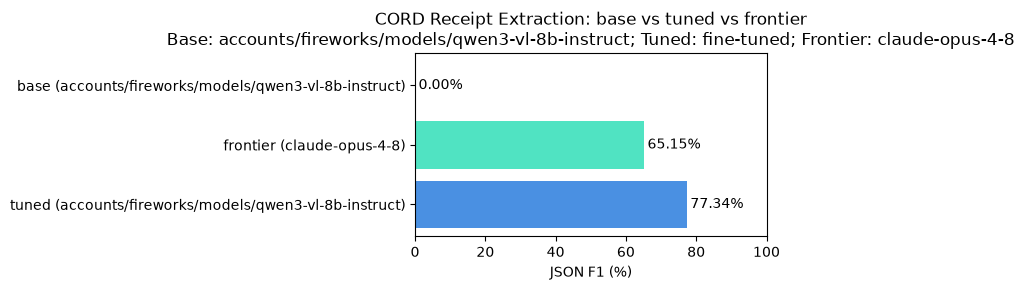

In [16]:
import matplotlib.pyplot as plt

# Bar chart of JSON F1: base vs tuned (+ frontier if it was evaluated). All vars are defined
# in the eval cells above (before, after, frontier, BASE_MODEL, FRONTIER_MODEL).
_short = BASE_MODEL.split("/")[-1]
labels = [f"base ({_short})", f"tuned ({_short})"]
values = [before, after]
if frontier is not None:
    labels.append(f"frontier ({FRONTIER_MODEL.split('/')[-1]})")
    values.append(frontier)

# Sort descending so the strongest model is on top.
order = sorted(range(len(values)), key=lambda i: values[i], reverse=True)
labels = [labels[i] for i in order]
values = [values[i] for i in order]

plt.figure(figsize=(8, 3))
bars = plt.barh(labels, [v * 100 for v in values], color=["#4a90e2", "#50e3c2", "#f5a623"][:len(labels)])
plt.xlabel("JSON F1 (%)")
plt.title("CORD receipt extraction — strict JSON F1")
for bar, v in zip(bars, values):
    plt.text(v * 100 + 1, bar.get_y() + bar.get_height() / 2, f"{v:.2%}", va="center", ha="left", fontsize=10)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Cleanup — tear down any leftover eval deployments

`eval_deployed` deletes each deployment as it finishes, but if an eval was
interrupted a `cordeval-*` deployment could linger. Run this to sweep them up.

In [8]:
# Tear down any leftover eval deployments (id prefix 'cordeval-'). Safe to re-run.
# Delete is blocked for ~1h after traffic, so fall back to scaling to 0 replicas.
def _teardown(dep_id):
    try:
        client.deployments.delete(dep_id, ignore_checks=True)   # ignore_checks bypasses the recent-traffic guard
        print("deleted deployment:", dep_id)
    except Exception as e:  # noqa: BLE001
        try:
            client.deployments.scale(dep_id, replica_count=0)
            print(f"scaled to 0 (delete blocked): {dep_id}")
        except Exception as e2:  # noqa: BLE001
            print(f"skip {dep_id}: {str(e2)[:120]}")

try:
    for d in client.deployments.list():
        did = d.name.split("/")[-1]
        if did.startswith("cordeval-"):
            _teardown(did)
    print("cleanup done.")
except Exception as e:  # noqa: BLE001
    print("could not list deployments:", str(e)[:150])

cleanup done.
